# 금융 데이터 다루기

# yfinance (Yahoo Finance API)
- 설명 : Yahoo Finance에서 주식 데이터를 가져오는 라이브러리
- 설치: `pip install yfinance`
- 주요 기능
    - 주식 정보 조회: 개별 주식의 과거 가격 데이터, 배당금 정보, 분할 정보 등을 조회할 수 있다.
    - 금융 데이터 다운로드: 일별, 주별, 월별 시계열 데이터를 Pandas DataFrame 형태로 쉽게 다운로드할 수 있다.
    - 다양한 금융 지표 제공: 시가, 고가, 저가, 종가, 거래량 등 주식 시장의 다양한 지표를 제공한다.
    - 복수 종목 데이터 동시 조회: 여러 주식 종목의 데이터를 한 번에 조회하는 기능을 지원한다.


## 1.1.yfinance 설치

- https://pypi.org/project/yfinance/

In [20]:
# %pip install yfinance
# uv add yfinance

In [21]:
import yfinance as yf
print(yf.__version__)

1.4.1


## 1.2.주식 데이터 가져오기
- yfinance에서 데이터를 불러올 때, Ticker(티커)라는 것을 인자로 넣어준다.
- Ticker는 야후 파이낸스 홈페이지에 원하는 종목을 검색하면 Ticker를 볼 수 있다.
- https://finance.yahoo.com/
- Ticker 목록 데이터 : https://www.nasdaq.com/market-activity/stocks/screener?page=1&rows_per_page=25

In [22]:
import pandas as pd

# 티커정보 가져오기(사이트에서 다운받아서 확인)
tickers = pd.read_csv('data/nasdaq.csv')
tickers.head()


,Symbol,Name,Last Sale,Net Change,% Change,Market Cap,Country,IPO Year,Volume,Sector,Industry
0,AAPL,Apple Inc. Common Stock,$219.5502,-7.9298,-3.486%,3.298099e+12,United States,1980,35917689,Technology,Computer Manufacturing
1,ASML,ASML Holding N.V. New York Registry Shares,$688.16,5.0500,0.739%,2.706421e+11,Netherlands,1995,939999,Technology,Industrial Machinery/Components
2,AVGO,Broadcom Inc. Common Stock,$190.8889,6.4389,3.491%,8.947643e+11,United States,2009,19348035,Technology,Semiconductors
3,GOOG,Alphabet Inc. Class C Capital Stock,$165.48,-2.3300,-1.388%,2.017201e+12,United States,2004,9759522,Technology,Computer Software: Programming Data Processing
4,GOOGL,Alphabet Inc. Class A Common Stock,$163.545,-2.3250,-1.402%,1.993614e+12,United States,2004,16025527,Technology,Computer Software: Programming Data Processing


In [23]:
tsmc = yf.download('TSM', start='2025-06-02', end='2026-06-01')
tsmc = tsmc.reset_index()
tsmc.columns = tsmc.columns.droplevel(1)
tsmc.head()

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
0,2025-06-02,192.456329,192.772422,189.848628,190.678347,7447400
1,2025-06-03,195.192444,195.745590,191.271012,191.972332,9548300
2,2025-06-04,199.923843,201.533907,197.928567,198.916333,13531100
3,2025-06-05,200.852325,203.242717,199.805296,202.373493,12214300
4,2025-06-06,202.669846,203.766267,200.743705,201.089429,8532000


In [24]:
tsmc.info()

<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype        
---  ------  --------------  -----        
 0   Date    250 non-null    datetime64[s]
 1   Close   250 non-null    float64      
 2   High    250 non-null    float64      
 3   Low     250 non-null    float64      
 4   Open    250 non-null    float64      
 5   Volume  250 non-null    int64        
dtypes: datetime64[s](1), float64(4), int64(1)
memory usage: 11.8 KB


In [25]:
tsmc_info = yf.Ticker('TSM')
tsmc_info.info

{'address1': 'Hsinchu Science Park',
 'address2': 'No. 8, Li-Hsin Road 6',
 'city': 'Hsinchu City',
 'zip': '300096',
 'country': 'Taiwan',
 'phone': '886 3 563 6688',
 'fax': '886 3 563 7000',
 'website': 'https://www.tsmc.com',
 'industry': 'Semiconductors',
 'industryKey': 'semiconductors',
 'industryDisp': 'Semiconductors',
 'sector': 'Technology',
 'sectorKey': 'technology',
 'sectorDisp': 'Technology',
 'longBusinessSummary': 'Taiwan Semiconductor Manufacturing Company Limited, together with its subsidiaries, manufactures, packages, tests, and sells integrated circuits and other semiconductor devices in Taiwan, China, Europe, the Middle East, Africa, Japan, the United States, and internationally. It provides various wafer fabrication processes, such as processes to manufacture complementary metal- oxide-semiconductor (CMOS) logic, mixed-signal, radio frequency, embedded memory, bipolar CMOS mixed-signal, and others. The company also involved in providing customer and engineering 

In [26]:
pal = yf.Ticker('PLTR')
pal.info

{'address1': '19505 Biscayne Blvd',
 'address2': 'Suite 2350',
 'city': 'Aventura',
 'state': 'FL',
 'zip': '33180',
 'country': 'United States',
 'phone': '720 358 3679',
 'website': 'https://www.palantir.com',
 'industry': 'Software - Infrastructure',
 'industryKey': 'software-infrastructure',
 'industryDisp': 'Software - Infrastructure',
 'sector': 'Technology',
 'sectorKey': 'technology',
 'sectorDisp': 'Technology',
 'longBusinessSummary': "Palantir Technologies Inc. builds and deploys software platforms for the intelligence community to assist in counterterrorism investigations and operations in the United States, the United Kingdom, and internationally. It provides Palantir Gotham integrates with other platforms for defense offerings which enables users to see, understand, and act in the modern battlespace; operations centers to the tactical edge; integrating data from domains and sensors in near real-time; and situational awareness and accelerating operational decision-making, 

- 특정 기간의 주가 데이터 가져오기

In [27]:
# 최근 1년 데이터를 간단히 가져옴
# start, end로 기간을 지정하지 않아도 됨
df1 = pal.history(period='1y')
df1.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-06-02 00:00:00-04:00,131.434998,134.479996,128.860001,132.039993,93218700,0.0,0.0
2025-06-03 00:00:00-04:00,133.070007,135.279999,130.100006,133.169998,91297700,0.0,0.0
2025-06-04 00:00:00-04:00,132.800003,132.949997,125.580002,130.009995,97306300,0.0,0.0
2025-06-05 00:00:00-04:00,129.270004,132.850006,118.930000,119.910004,131055900,0.0,0.0
2025-06-06 00:00:00-04:00,123.730003,128.130005,121.919998,127.720001,87175100,0.0,0.0


## 1.3.주가 데이터 시각화

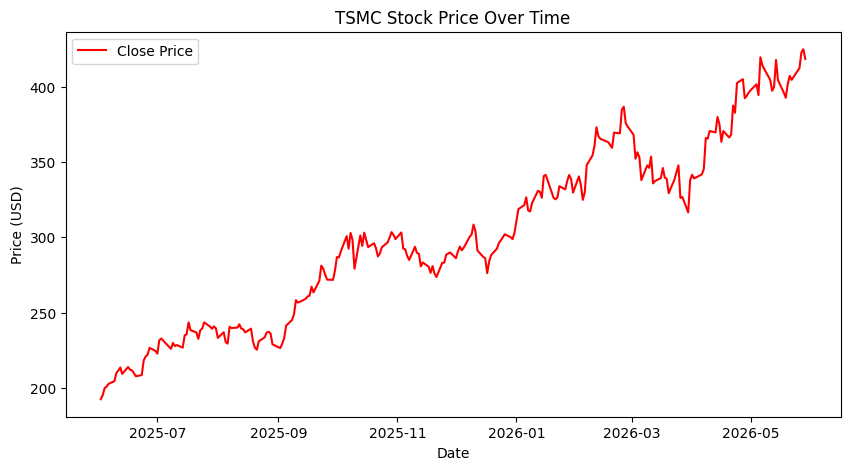

In [28]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,5))
plt.plot(tsmc['Date'], tsmc['Close'], label='Close Price', color='red')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.title('TSMC Stock Price Over Time')
plt.legend()
plt.show()

In [29]:
# 캔들 차트로 그리기
import plotly.graph_objects as go
import plotly.express as px



fig = go.Figure(data=[go.Candlestick(x=tsmc['Date'],
                                     open=tsmc['Open'],
                                     high=tsmc['High'],
                                     low=tsmc['Low'],
                                     close=tsmc['Close'])])
fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()

## 1.4.주식 데이터 분석
- 아까 csv파일에 담았던 Ticker 목록 불러와서 주식 데이터 분석해보기

In [30]:
stock = yf.download(tickers['Symbol'].tolist(), start='2025-06-01', end='2026-05-31')
stock

[*********************100%***********************]  8 of 8 completed


Price            Close                                                   \
Ticker            AAPL         ASML        AVGO        GOOG       GOOGL   
Date                                                                      
2025-06-02  200.902985   740.725342  246.711014  169.783020  168.445923   
2025-06-03  202.466782   741.439697  254.785614  167.132217  165.605759   
2025-06-04  202.018539   737.004517  258.981598  168.806412  167.469315   
2025-06-05  199.837204   741.945801  257.840820  169.224960  167.628754   
2025-06-06  203.114197   747.164856  244.945297  174.317368  173.079849   
...                ...          ...         ...         ...         ...   
2026-05-22  308.820007  1632.900024  414.140015  379.380005  382.970001   
2026-05-26  308.329987  1632.030029  422.010010  384.839996  388.880005   
2026-05-27  310.850006  1597.869995  421.859985  384.829987  388.829987   
2026-05-28  312.510010  1605.770020  426.579987  386.119995  390.130005   
2026-05-29  312.059998  1612.760010  446.769989  376.429993  380.339996   

Price                                                 High               ...  \
Ticker            META        MSFT        NVDA        AAPL         ASML  ...   
Date                                                                     ...   
2025-06-02  668.813477  458.309235  137.347641  201.331293   741.142059  ...   
2025-06-03  664.776123  459.301300  141.186722  202.964806   742.729577  ...   
2025-06-04  685.810425  460.194122  141.886566  205.425023   746.916829  ...   
2025-06-05  682.490784  463.973938  139.957016  203.940919   750.578166  ...   
2025-06-06  695.540100  466.652557  141.686600  204.887162   756.174210  ...   
...                ...         ...         ...         ...          ...  ...   
2026-05-22  610.260010  418.570007  215.330002  311.399994  1653.530029  ...   
2026-05-26  612.340027  416.029999  214.860001  311.820007  1648.010010  ...   
2026-05-27  635.260010  412.670013  212.600006  313.260010  1639.130005  ...   
2026-05-28  635.289978  426.989990  214.250000  312.799988  1627.530029  ...   
2026-05-29  632.510010  450.239990  211.139999  315.000000  1654.199951  ...   

Price             Open                Volume                               \
Ticker            MSFT        NVDA      AAPL     ASML      AVGO      GOOG   
Date                                                                        
2025-06-02  453.517522  135.458087  35423300   812600  19197000  24742900   
2025-06-03  457.813186  138.747294  46381600  1085100  30380200  25386700   
2025-06-04  460.323097  142.156507  43604000  1160000  31536000  18508700   
2025-06-05  461.275491  142.136495  55126100  1506500  41970900  25375400   
2025-06-06  466.364847  142.476407  46607700  1345100  41146700  22258100   
...                ...         ...       ...      ...       ...       ...   
2026-05-22  419.540009  220.899994  43670200  1666700  14086400  13382800   
2026-05-26  416.429993  216.539993  48000500  1651000  22562900  16150900   
2026-05-27  411.010010  214.119995  50430900  1361600  17601000  16893100   
2026-05-28  412.980011  211.279999  48220400   971600  17855600  20795400   
2026-05-29  432.549988  214.580002  70026800  1069400  41798400  48018600   

Price                                                
Ticker         GOOGL      META      MSFT       NVDA  
Date                                                 
2025-06-02  38612300  15766300  16626500  197663100  
2025-06-03  45084900  11585000  15743800  225578800  
2025-06-04  26900800  14031900  14162700  167120800  
2025-06-05  36379100  13083100  20131700  231397900  
2025-06-06  35731800  11728000  15285600  153986200  
...              ...       ...       ...        ...  
2026-05-22  20442100  11688600  22390300  169275700  
2026-05-26  27747400  12234200  30398000  187202600  
2026-05-27  23087300  23143600  28901500  167601200  
2026-05-28  24357500  16772400  47250500  143996000  
2026-05-29  44415800  19806500  79654400  28941

In [31]:
# 2026년 5월 31일 기준으로 1년간 가장 많이 상승(하락) 종목 찾기

stock = stock.reset_index()
starts = stock[stock['Date'] == '2025-06-02']['Open'].transpose()
starts = starts.reset_index()

ends = stock[stock['Date'] == '2026-05-29']['Close'].transpose()
ends = ends.reset_index()

starts.columns = ['Ticker', 'START']
ends.columns = ['Ticker', 'END']

stocks_ = pd.merge(starts, ends, how='left', left_on='Ticker', right_on='Ticker')
stocks_['rate'] = (stocks_['END'] - stocks_['START']) / stocks_['START']
stocks_ = stocks_.sort_values('rate', ascending=False)
stocks_

,Ticker,START,END,rate
4,GOOGL,167.260032,380.339996,1.273944
3,GOOG,168.427705,376.429993,1.234965
1,ASML,727.588239,1612.760010,1.216583
2,AVGO,241.294892,446.769989,0.851552
0,AAPL,199.488598,312.059998,0.564300
7,NVDA,135.458087,211.139999,0.558711
6,MSFT,453.517522,450.239990,-0.007227
5,META,642.385915,632.510010,-0.015374


- 시각화 해보기

In [34]:
fig = px.bar(stocks_, y='rate', x='Ticker')
fig.show()

- 거래량(Volumes) 확인해보기

In [35]:
volumes = stock['Volume'].sum().reset_index()
volumes.columns = ['Ticker', 'Volume']
volumes = volumes.sort_values(by='Volume', ascending=False)
volumes.head()

,Ticker,Volume
7,NVDA,44257560900
0,AAPL,12381008500
4,GOOGL,8630786300
6,MSFT,6766619400
2,AVGO,6206776600


In [38]:
fig = px.bar(volumes, y='Volume', x='Ticker')
fig.show()